In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# E-Commerce Customer Data Analysis

## Objective

The objective of this project is to clean, analyze, and extract
business insights from an e-commerce customer dataset.

The dataset contains customer demographic information,
purchase behavior, spending information, satisfaction scores,
and preferred product categories.

### Key Objectives

- Understand the structure and quality of the dataset
- Identify and handle missing and invalid values
- Clean inconsistent data
- Perform exploratory data analysis
- Identify customer behavior patterns
- Generate actionable business insights

In [2]:
df = pd.read_csv("../data/raw/customer_shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.shape

(3900, 18)

In [4]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
quality_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isna().sum().values,
    "Missing_Percentage": (df.isna().mean() * 100).round(2).values,
    "Unique_Values": df.nunique().values
})

quality_summary

,Column,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
0,Customer ID,int64,0,0.00,3900
1,Age,int64,0,0.00,53
2,Gender,object,0,0.00,2
3,Item Purchased,object,0,0.00,25
4,Category,object,0,0.00,4
5,Purchase Amount (USD),int64,0,0.00,81
6,Location,object,0,0.00,50
7,Size,object,0,0.00,4
8,Color,object,0,0.00,25
9,Season,object,0,0.00,4


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [9]:
df[numeric_cols].skew()

Customer ID              0.000000
Age                     -0.006380
Purchase Amount (USD)    0.012702
Review Rating            0.001355
Previous Purchases       0.003121
dtype: float64

In [10]:
df["Review Rating"].unique()

array([3.1, 3.5, 2.7, 2.9, 3.2, 2.6, 4.8, 4.1, 4.9, 4.5, 4.7, 2.8, 4.6,
       3.3, 4.4, 3.6, 5. , 4. , nan, 4.2, 3.7, 3.9, 3. , 3.8, 3.4, 4.3,
       2.5])

In [11]:
category_cols = df.select_dtypes(include='object').columns
for col in category_cols:
    print('*' * 50)
    print(df[col].value_counts())

**************************************************
Gender
Male      2652
Female    1248
Name: count, dtype: int64
**************************************************
Item Purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64
**************************************************
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64
**************************************************
Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota    

In [12]:
print("Total IDs:", df["Customer ID"].count())
print("Unique IDs:", df["Customer ID"].nunique())

Total IDs: 3900
Unique IDs: 3900


In [13]:
print(df["Review Rating"].median())
print(df["Review Rating"].mean())

3.8
3.750064716541548


In [14]:
df_clean = df.copy()

df_clean["Review Rating"] = df_clean["Review Rating"].fillna(
    df_clean["Review Rating"].median()
)


37 missing Review Rating values were imputed using the median rating of 3.8 to preserve the records while minimizing the influence of extreme values.

In [15]:
comparison = pd.DataFrame({
    "Before": df.isna().sum(),
    "After": df_clean.isna().sum()
})

comparison

,Before,After
Customer ID,0,0
Age,0,0
Gender,0,0
Item Purchased,0,0
Category,0,0
Purchase Amount (USD),0,0
Location,0,0
Size,0,0
Color,0,0
Season,0,0


In [16]:
df_clean.to_csv(
    "../data/clean/customer_shopping_behavior_cleaned.csv",
    index=False
)

# EDA

1. Customer Demography

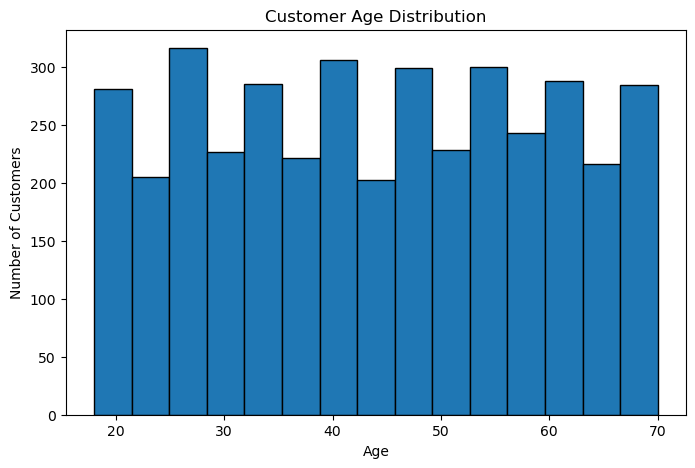

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean["Age"],bins=15,edgecolor="black")

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

The customer base is broadly distributed across the 18–70 age range, with no single age range dominating the overall population.

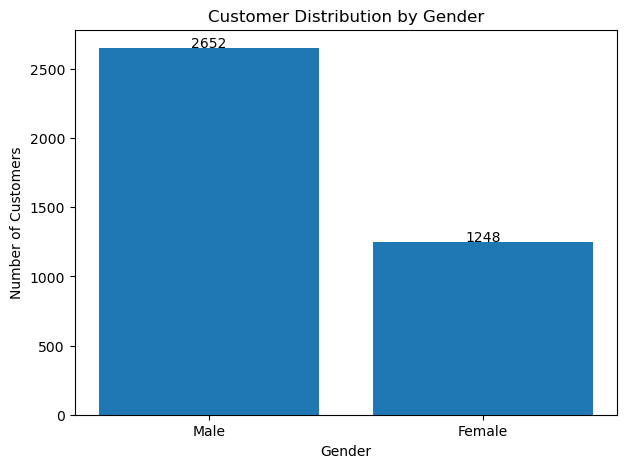

In [18]:
gender_counts = df_clean["Gender"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(gender_counts.index,gender_counts.values)

for i,count in enumerate(gender_counts.values):
  plt.text(i,count + 3,str(count),ha="center")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

The dataset contains 2,652 male customers and 1,248 female customers, indicating that male customers represent a larger share of the observed customer base.

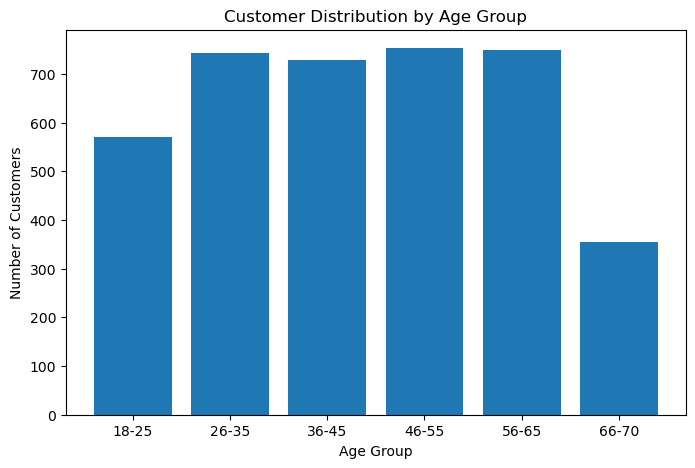

In [19]:
bins = [17, 25, 35, 45, 55, 65, 70]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66-70"
]

df_clean["Age Group"] = pd.cut(df_clean["Age"],bins=bins,labels=labels)

age_group_counts = df_clean["Age Group"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(age_group_counts.index,age_group_counts.values)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

Customers aged 26–65 account for most of the observed customer base, while the 66–70 group has considerably fewer customers.

In [20]:
age_spending = (
    df_clean
    .groupby("Age Group", observed=True)["Purchase Amount (USD)"]
    .agg(["count", "mean", "sum"])
    .round(2)
)

age_spending

,count,mean,sum
Age Group,,,
18-25,571,60.65,34630
26-35,742,59.76,44342
36-45,729,59.31,43234
46-55,753,60.58,45619
56-65,750,59.14,44352
66-70,355,58.88,20904


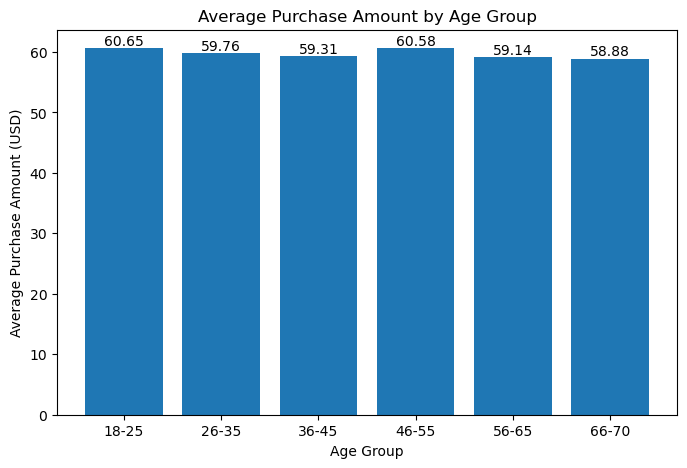

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(age_spending.index,age_spending["mean"])

for i,value in enumerate(age_spending["mean"]):
  plt.text(i,value,str(value),ha="center", va='bottom')

plt.title("Average Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

Average purchase amounts are relatively consistent across age groups, ranging from $58.88 to $60.65. This suggests that age-group differences in average purchase value are small within this dataset.

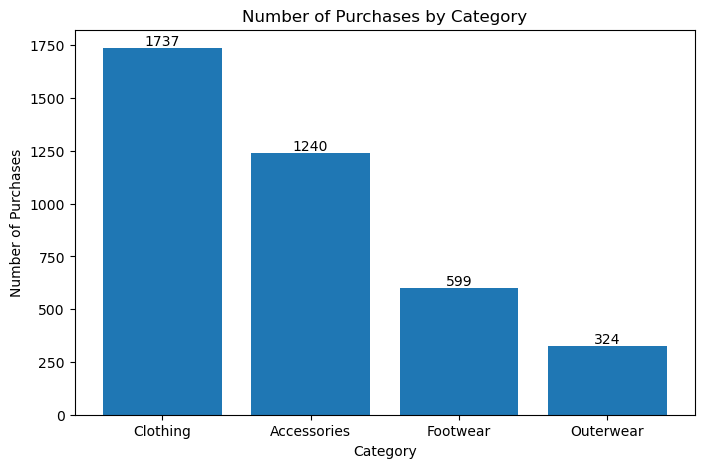

In [22]:
category_counts = df_clean['Category'].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    category_counts.index,
    category_counts.values
)

for i,value in enumerate(category_counts.values):
  plt.text(i,value,str(value),ha="center", va='bottom')


plt.title("Number of Purchases by Category")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

plt.show()

Clothing is the most frequently purchased category in the dataset.

In [23]:
category_sales = (
    df_clean
    .groupby("Category")["Purchase Amount (USD)"]
    .agg(["count", "sum", "mean"])
    .round(2)
)

category_sales

,count,sum,mean
Category,,,
Accessories,1240,74200,59.84
Clothing,1737,104264,60.03
Footwear,599,36093,60.26
Outerwear,324,18524,57.17


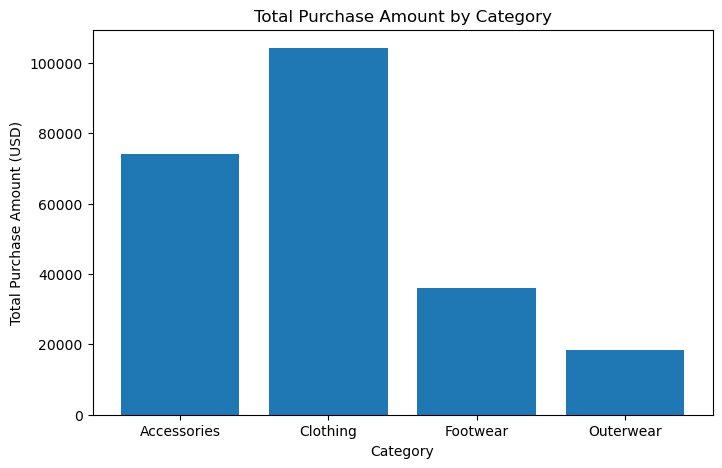

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_sales.index,
    category_sales["sum"]
)

plt.title("Total Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Total Purchase Amount (USD)")

plt.show()

Average purchase values are relatively similar across categories, while Clothing's much higher purchase volume makes it the largest contributor to total sales.

In [25]:
top_items = (
    df_clean["Item Purchased"]
    .value_counts()
    .head(10)
)

top_items

Item Purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Name: count, dtype: int64

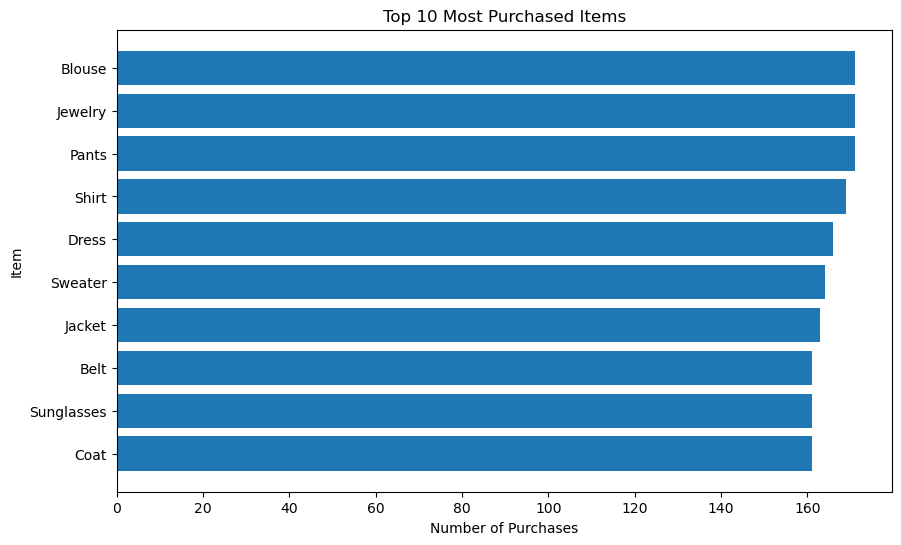

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_items.index[::-1],
    top_items.values[::-1]
)

plt.title("Top 10 Most Purchased Items")
plt.xlabel("Number of Purchases")
plt.ylabel("Item")

plt.show()

The top 10 products have relatively similar purchase volumes, with Blouse, Jewelry, and Pants recording the highest counts at 171 purchases each

In [27]:
top_item_sales = (
    df_clean
    .groupby("Item Purchased")["Purchase Amount (USD)"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
    .head(10)
    .round(2)
)

top_item_sales

,count,sum,mean
Item Purchased,,,
Blouse,171,10410,60.88
Shirt,169,10332,61.14
Dress,166,10320,62.17
Pants,171,10090,59.01
Jewelry,171,10010,58.54
Sunglasses,161,9649,59.93
Belt,161,9635,59.84
Scarf,157,9561,60.90
Sweater,164,9462,57.70


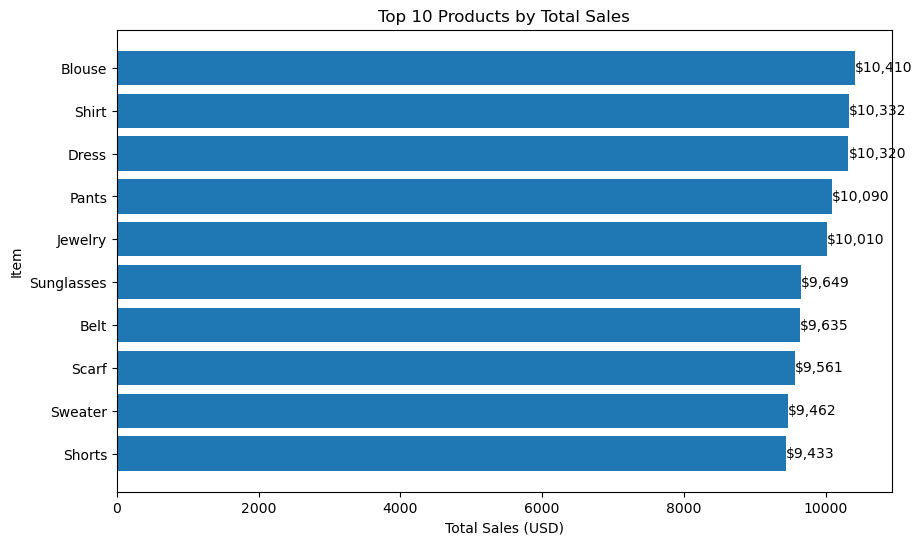

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_item_sales.index[::-1],
    top_item_sales["sum"][::-1]
)

for i, value in enumerate(top_item_sales["sum"][::-1]):
    plt.text(
        value,
        i,
        f"${value:,.0f}",
        va="center"
    )

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales (USD)")
plt.ylabel("Item")

plt.show()

Revenue is relatively evenly distributed among the top-selling products. Blouse generated the highest total sales at 10410
while Dress had the highest average purchase value among these products at $62.17.

## Spending Analysis

Question 1 — What is the overall sales performance?

In [29]:
total_sales = df_clean["Purchase Amount (USD)"].sum()
average_purchase = df_clean["Purchase Amount (USD)"].mean()
median_purchase = df_clean["Purchase Amount (USD)"].median()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Average Purchase: ${average_purchase:,.2f}")
print(f"Median Purchase: ${median_purchase:,.2f}")

Total Sales: $233,081.00
Average Purchase: $59.76
Median Purchase: $60.00


Question 2 — What does the purchase amount distribution look like

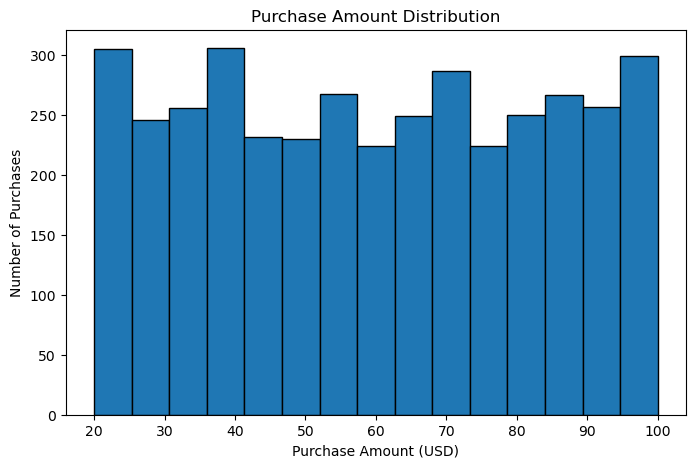

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["Purchase Amount (USD)"],
    bins=15,
    edgecolor="black"
)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Number of Purchases")

plt.show()

Purchase amounts are broadly distributed across the $20–$100 range, with no strong concentration at a particular price point.

Question 3 — Discount vs non-discount purchases

In [31]:
discount_analysis = (
    df_clean
    .groupby("Discount Applied")["Purchase Amount (USD)"]
    .agg(["count", "mean", "sum"])
    .round(2)
)

discount_analysis

,count,mean,sum
Discount Applied,,,
No,2223,60.13,133670
Yes,1677,59.28,99411


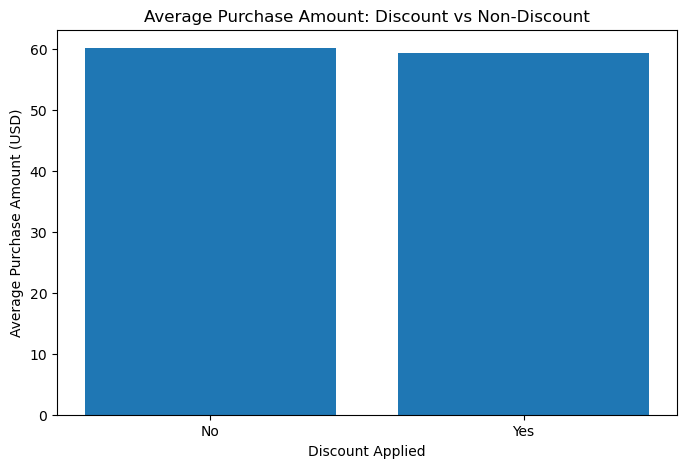

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    discount_analysis.index,
    discount_analysis["mean"]
)

plt.title("Average Purchase Amount: Discount vs Non-Discount")
plt.xlabel("Discount Applied")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

Non-discounted transactions have a slightly higher average purchase value (60.13) than discounted transactions (59.28). The difference is only $0.85, so the dataset does not show a large difference in transaction value between the two groups.

## Subscription Analysis

Question 1 — How many customers are subscribed?

In [33]:
subscription_counts = df_clean["Subscription Status"].value_counts()

subscription_counts

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

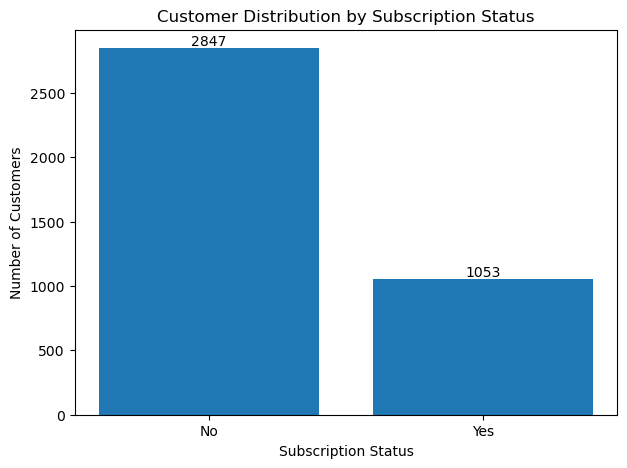

In [34]:
plt.figure(figsize=(7, 5))

plt.bar(
    subscription_counts.index,
    subscription_counts.values
)

for i, value in enumerate(subscription_counts.values):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.title("Customer Distribution by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Number of Customers")

plt.show()

Most customers (73%) are non-subscribers, while 27% have an active subscription. The dataset therefore has a substantially larger non-subscriber customer base.

Question 2 — Does subscription status relate to purchase value?

In [35]:
subscription_analysis = (
    df_clean
    .groupby("Subscription Status")["Purchase Amount (USD)"]
    .agg(["count", "mean", "sum"])
    .round(2)
)

subscription_analysis

,count,mean,sum
Subscription Status,,,
No,2847,59.87,170436
Yes,1053,59.49,62645


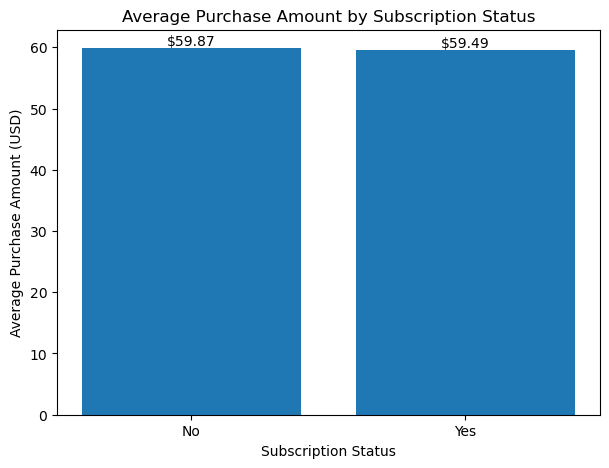

In [36]:
plt.figure(figsize=(7, 5))

plt.bar(
    subscription_analysis.index,
    subscription_analysis["mean"]
)

for i, value in enumerate(subscription_analysis["mean"]):
    plt.text(
        i,
        value,
        f"${value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Purchase Amount by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

Average transaction value is very similar between subscribers and non-subscribers, differing by only $0.38.

Question 3 — Subscription and purchase frequency

In [37]:
subscription_frequency_pct = pd.crosstab(
    df_clean["Subscription Status"],
    df_clean["Frequency of Purchases"],
    normalize="index"
).mul(100).round(2)

subscription_frequency_pct

Frequency of Purchases,Annually,Bi-Weekly,Every 3 Months,Fortnightly,Monthly,Quarterly,Weekly
Subscription Status,,,,,,,
No,14.47,14.3,15.10,13.66,14.19,14.86,13.42
Yes,15.19,13.3,14.62,14.53,14.15,13.30,14.91


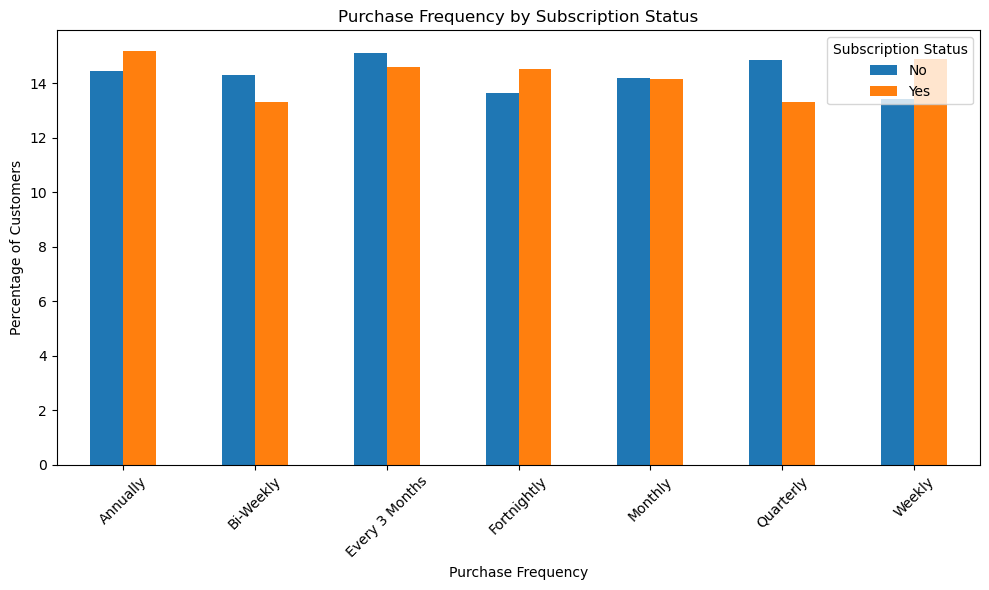

In [38]:
subscription_frequency_pct.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Purchase Frequency by Subscription Status")
plt.xlabel("Purchase Frequency")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=45)

plt.legend(title="Subscription Status")

plt.tight_layout()
plt.show()

Purchase frequency is relatively evenly distributed across all frequency categories for both subscribers and non-subscribers. The overall distribution is similar between the two groups, suggesting that subscription status does not correspond to a major difference in purchase-frequency patterns in this dataset.

## Payment Method Analysis

Question 1 — Which payment methods are most commonly used?

In [39]:
payment_counts = df_clean["Payment Method"].value_counts()

payment_counts

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

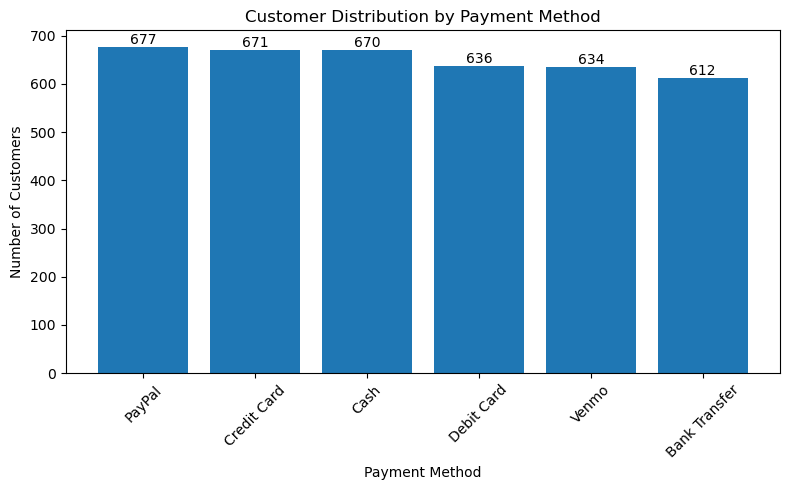

In [40]:
plt.figure(figsize=(8, 5))

plt.bar(
    payment_counts.index,
    payment_counts.values
)

for i, value in enumerate(payment_counts.values):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.title("Customer Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Customer payment methods are relatively evenly distributed, with PayPal, Credit Card, and Cash being the most commonly used methods. Bank Transfer has the lowest usage, but the overall difference across payment methods is relatively small.

Question 2 — Does payment method affect purchase value?

In [41]:
payment_analysis = (
    df_clean
    .groupby("Payment Method")["Purchase Amount (USD)"]
    .agg(["count", "mean", "sum"])
    .round(2)
)

payment_analysis

,count,mean,sum
Payment Method,,,
Bank Transfer,612,59.71,36544
Cash,670,59.70,40002
Credit Card,671,60.07,40310
Debit Card,636,60.92,38742
PayPal,677,59.25,40109
Venmo,634,58.95,37374


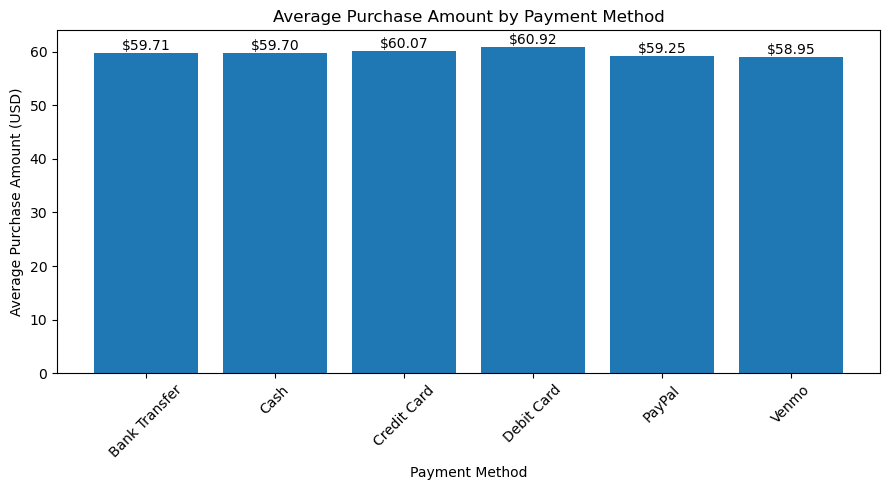

In [42]:
plt.figure(figsize=(9, 5))

plt.bar(
    payment_analysis.index,
    payment_analysis["mean"]
)

for i, value in enumerate(payment_analysis["mean"]):
    plt.text(
        i,
        value,
        f"${value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Purchase Amount by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Purchase Amount (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Average purchase amounts are relatively consistent across payment methods, ranging from $58.95 to $60.92. This suggests that payment method does not correspond to a substantial difference in average purchase value in this dataset.

Question 3 — Payment method and subscription status

In [43]:
payment_subscription = pd.crosstab(
    df_clean["Payment Method"],
    df_clean["Subscription Status"]
)

payment_subscription

Subscription Status,No,Yes
Payment Method,,
Bank Transfer,455,157
Cash,497,173
Credit Card,492,179
Debit Card,446,190
PayPal,497,180
Venmo,460,174


In [44]:
payment_subscription_pct = pd.crosstab(
    df_clean["Payment Method"],
    df_clean["Subscription Status"],
    normalize="index"
).mul(100).round(2)

payment_subscription_pct

Subscription Status,No,Yes
Payment Method,,
Bank Transfer,74.35,25.65
Cash,74.18,25.82
Credit Card,73.32,26.68
Debit Card,70.13,29.87
PayPal,73.41,26.59
Venmo,72.56,27.44


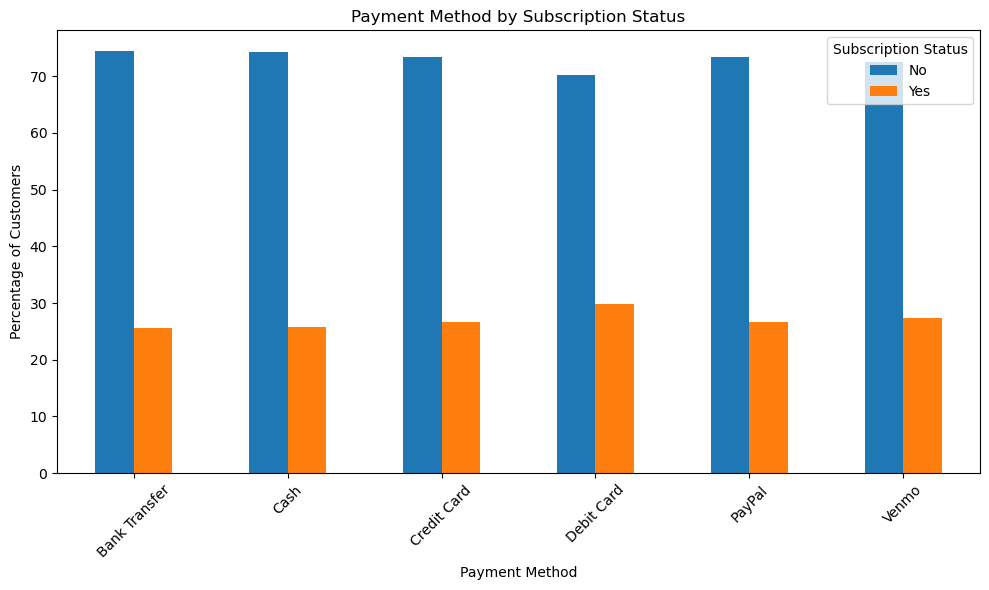

In [45]:
payment_subscription_pct.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Payment Method by Subscription Status")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=45)
plt.legend(title="Subscription Status")

plt.tight_layout()
plt.show()

Subscription status is relatively consistent across payment methods, with subscribers representing approximately 26%–30% of customers depending on the payment method. Debit Card has the highest subscriber proportion at 29.87%, while Bank Transfer has the lowest at 25.65%. Overall, payment method does not show a substantial difference in subscription distribution.

## Season Analysis

In [46]:
season_counts = df_clean["Season"].value_counts()

season_counts

Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64

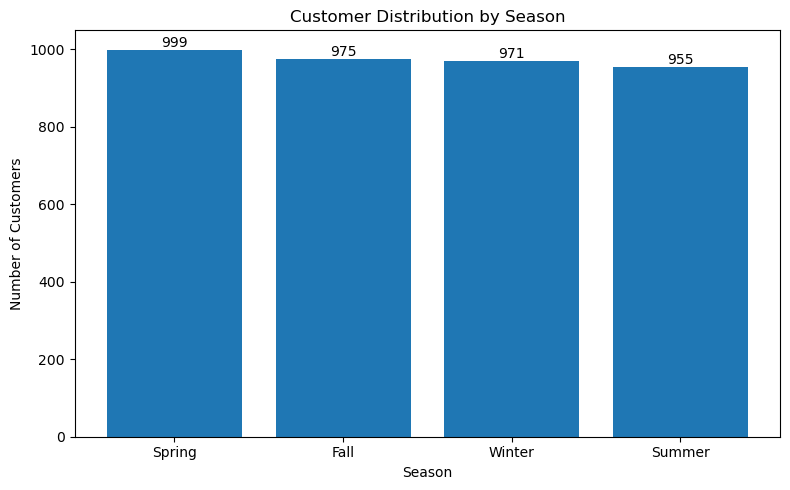

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_counts.index,
    season_counts.values
)

for i, value in enumerate(season_counts.values):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.title("Customer Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

The customer distribution is quite balanced across all four seasons.

Spring has the highest number of customers: 999  
Summer has the lowest: 955  
Difference = only 44 customers

So there isn't a large seasonal imbalance in the customer base.

In [48]:
season_analysis = (
    df_clean
    .groupby("Season")["Purchase Amount (USD)"]
    .agg(["count", "mean", "sum"])
    .round(2)
)

season_analysis

,count,mean,sum
Season,,,
Fall,975,61.56,60018
Spring,999,58.74,58679
Summer,955,58.41,55777
Winter,971,60.36,58607


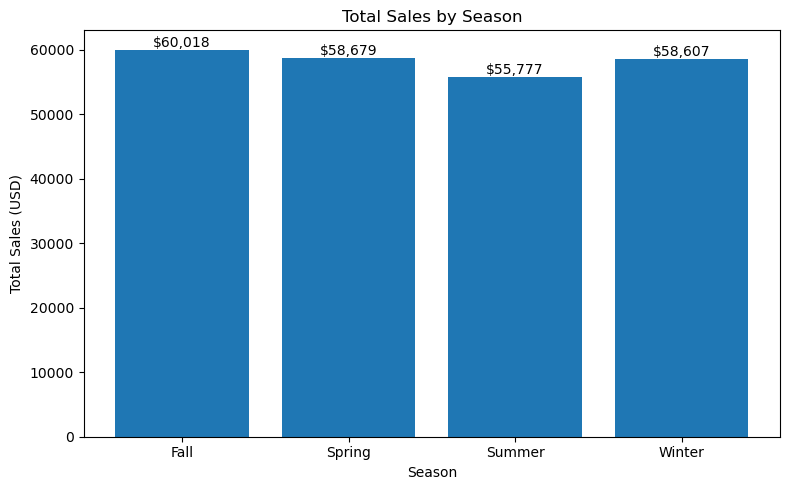

In [49]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_analysis.index,
    season_analysis["sum"]
)

for i, value in enumerate(season_analysis["sum"]):
    plt.text(
        i,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.title("Total Sales by Season")
plt.xlabel("Season")
plt.ylabel("Total Sales (USD)")

plt.tight_layout()
plt.show()

Fall has the highest average purchase amount at 61.56 and the highest total sales at 60,018.  
Spring has the largest customer count at 999, but its average purchase is lower than Fall and Winter.  
Summer has the lowest total sales at 55,777 and the lowest average purchase at $58.41.  
Overall, the differences are relatively small, so sales and purchase behavior are fairly consistent across seasons.  

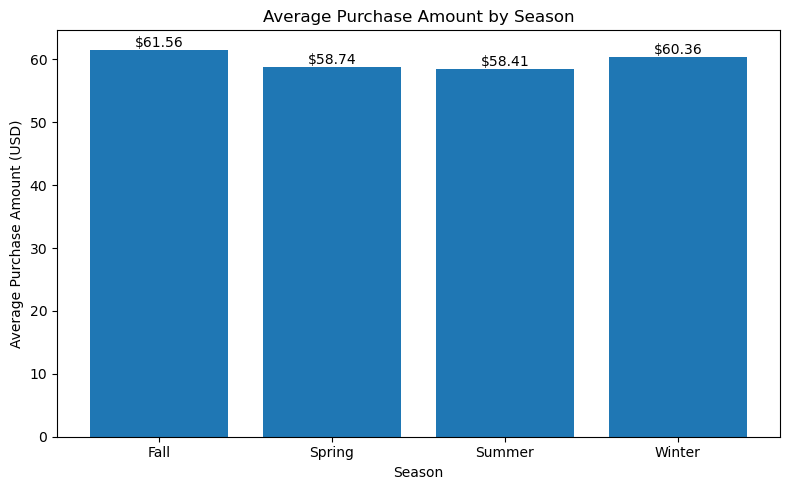

In [50]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_analysis.index,
    season_analysis["mean"]
)

for i, value in enumerate(season_analysis["mean"]):
    plt.text(
        i,
        value,
        f"${value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Purchase Amount by Season")
plt.xlabel("Season")
plt.ylabel("Average Purchase Amount (USD)")

plt.tight_layout()
plt.show()

## Review Rating Analysis

Question 1 — How are customer ratings distributed?

In [51]:
rating_counts = df_clean["Review Rating"].value_counts().sort_index()

rating_counts

Review Rating
2.5     66
2.6    158
2.7    154
2.8    136
2.9    166
3.0    162
3.1    156
3.2    152
3.3    146
3.4    182
3.5    152
3.6    147
3.7    149
3.8    178
3.9    162
4.0    181
4.1    148
4.2    169
4.3    147
4.4    158
4.5    139
4.6    170
4.7    148
4.8    144
4.9    162
5.0     68
Name: count, dtype: int64

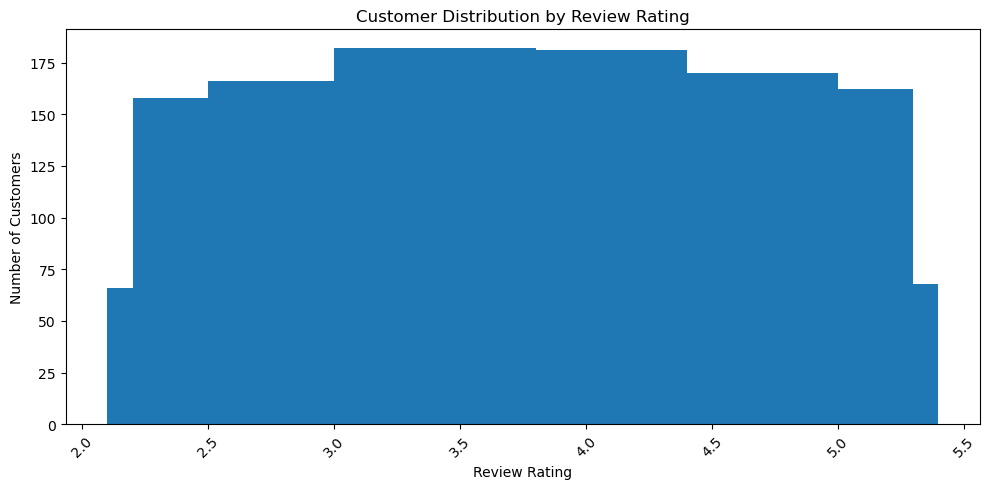

In [52]:
plt.figure(figsize=(10, 5))

plt.bar(
    rating_counts.index,
    rating_counts.values
)

plt.title("Customer Distribution by Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Question 2 — Does review rating relate to purchase amount?

In [53]:
rating_analysis = (
    df_clean
    .groupby("Review Rating")["Purchase Amount (USD)"]
    .agg(["count", "mean", "sum"])
    .round(2)
)

rating_analysis

,count,mean,sum
Review Rating,,,
2.5,66,62.29,4111
2.6,158,59.77,9443
2.7,154,59.36,9142
2.8,136,57.07,7761
2.9,166,56.20,9329
3.0,162,60.73,9838
3.1,156,58.78,9170
3.2,152,61.32,9320
3.3,146,59.79,8730


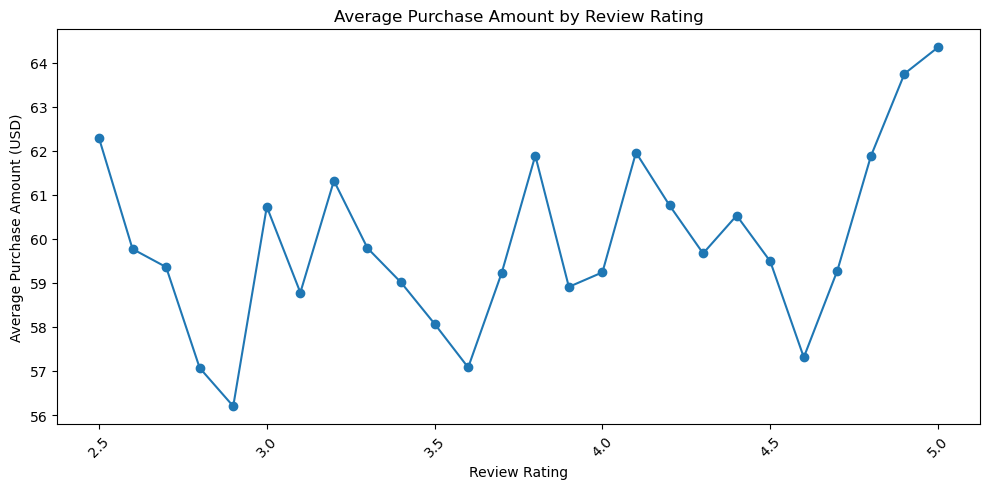

In [54]:
plt.figure(figsize=(10, 5))

plt.plot(
    rating_analysis.index,
    rating_analysis["mean"],
    marker="o"
)

plt.title("Average Purchase Amount by Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Average Purchase Amount (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



Average purchase amount fluctuates across review ratings, ranging approximately from $56 to $64. There is no clear consistent upward or downward trend, suggesting that review rating does not have a strong linear relationship with purchase amount in this dataset.

In [55]:
rating_category = (
    df_clean
    .groupby("Category")["Review Rating"]
    .agg(["count", "mean"])
    .round(2)
    .sort_values("mean", ascending=False)
)

rating_category

,count,mean
Category,,
Footwear,599,3.79
Accessories,1240,3.77
Outerwear,324,3.75
Clothing,1737,3.72


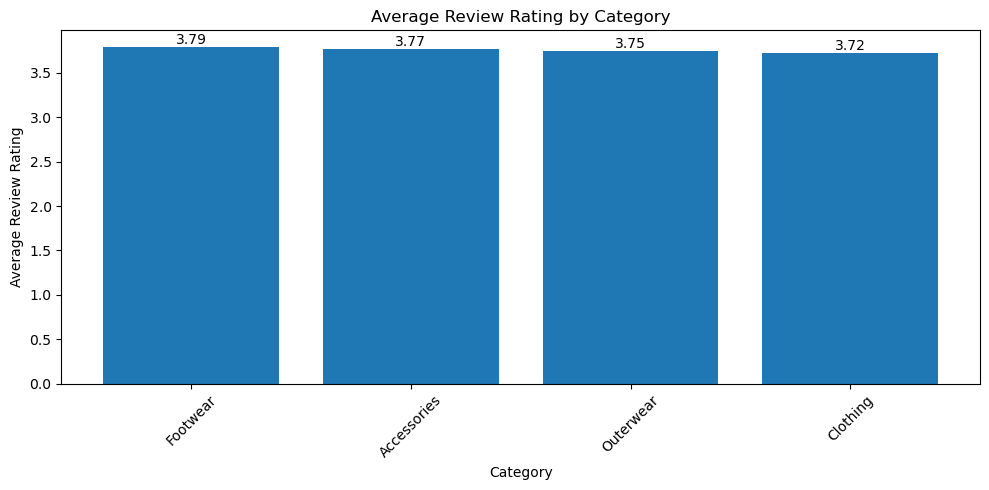

In [56]:
plt.figure(figsize=(10, 5))

plt.bar(
    rating_category.index,
    rating_category["mean"]
)

for i, value in enumerate(rating_category["mean"]):
    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Review Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Review Rating")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Average review ratings are very similar across product categories, ranging from 3.72 to 3.79. Footwear has the highest average rating at 3.79, while Clothing has the lowest at 3.72. Overall, product category does not show a major difference in customer ratings.

## Correlation Analysis

In [57]:
numeric_cols = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

correlation_matrix = df_clean[numeric_cols].corr().round(2)

correlation_matrix

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Age,1.00,-0.01,-0.02,0.04
Purchase Amount (USD),-0.01,1.00,0.03,0.01
Review Rating,-0.02,0.03,1.00,0.00
Previous Purchases,0.04,0.01,0.00,1.00


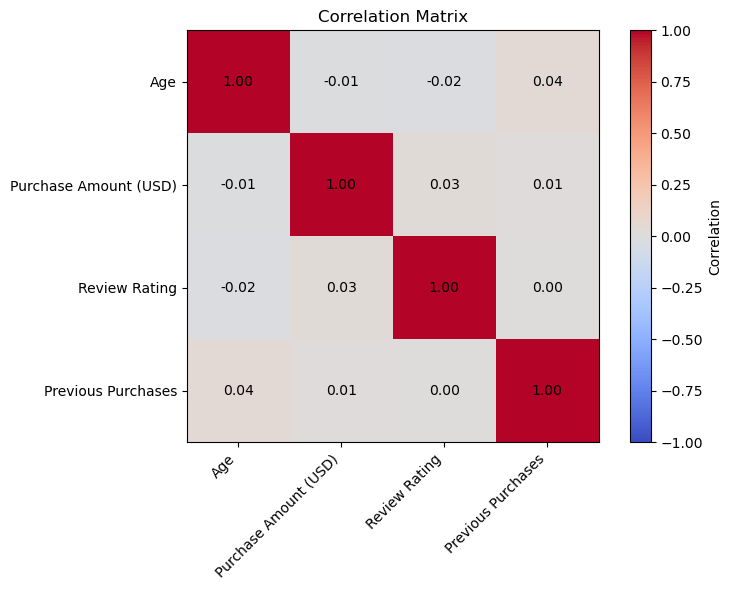

In [58]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


The correlation analysis shows that all numerical variables have very weak linear relationships with each other. The strongest observed correlation is between Age and Previous Purchases (0.04), which is still negligible. Purchase Amount also shows almost no linear relationship with Age, Review Rating, or Previous Purchases. Overall, no meaningful linear correlation is observed among the numerical variables in this dataset.

## Final EDA Summary

- The dataset contains **3,900 customers** with information about demographics, purchases, products, subscriptions, payments, shipping, discounts, and ratings.
- Customer distribution across **seasons and payment methods is relatively balanced**, with no major concentration in a single group.
- **Purchase amounts are fairly consistent** across payment methods and seasons, indicating limited variation based on these factors.
- **Subscription customers represent a smaller portion** of the customer base, while non-subscribers make up the majority across all payment methods.
- **Review ratings are broadly distributed between 2.5 and 5.0**, with average ratings across product categories remaining quite similar.
- The relationship between **review ratings and purchase amount is very weak**, suggesting that higher ratings do not necessarily correspond to higher spending.
- **Correlation analysis shows very weak relationships** among the numerical variables, with no meaningful linear correlation identified.
- Overall, the EDA provides a clear understanding of **customer behavior, purchasing patterns, subscription status, payment preferences, seasonal distribution, and customer satisfaction**.

### Conclusion

Overall, the dataset shows a relatively balanced customer base with consistent purchasing behavior across different payment methods and seasons. Subscription status and customer ratings provide useful segmentation insights, while the weak correlations indicate that customer purchasing behavior is influenced by factors beyond the numerical variables analyzed.